# Example 05C: Compare Ensemble Outputs

This notebook compares completed sibling simulations from notebook 05B using the outlet flow-component files. The same workflow can compare one base model with many realizations, or several base models by loading multiple simulation manifests and assigning each one a `base_model` label.

In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "sewertris").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EXAMPLES_DIR = PROJECT_ROOT / "examples"
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import sewertris as sp

ENSEMBLE_ROOT = EXAMPLES_DIR / "output_example_5_ensembles"
SIMULATION_MANIFEST = ENSEMBLE_ROOT / "simulation_manifest.csv"
FIGURE_PATH = ENSEMBLE_ROOT / "ensemble_outlet_flow_comparison.png"

print("Simulation manifest:", SIMULATION_MANIFEST)

Simulation manifest: /Users/kevinblanco/Documents/Sewertris/examples/output_example_5_ensembles/simulation_manifest.csv


## Load Simulation Manifests

Add more entries to `MANIFEST_SOURCES` when comparing ensembles produced from different base models. Each manifest should contain the columns written by notebook 05B, including `ensemble`, `realization`, `project_file`, and `flows_path`.

In [2]:
MANIFEST_SOURCES = [
    {
        "base_model": "Stillwater V2 base",
        "path": SIMULATION_MANIFEST,
    },
    # Example for a second base model:
    # {
    #     "base_model": "Stillwater alternate base",
    #     "path": EXAMPLES_DIR / "output_example_5_ensembles_alt" / "simulation_manifest.csv",
    # },
]

manifests = []
for source in MANIFEST_SOURCES:
    path = Path(source["path"])
    if not path.exists():
        print(f"Missing manifest: {path}")
        continue
    manifest = pd.read_csv(path)
    manifest["base_model"] = source["base_model"]
    manifest["manifest_path"] = str(path)
    manifests.append(manifest)

if manifests:
    simulation_manifest = pd.concat(manifests, ignore_index=True)
    simulation_manifest["flows_exists"] = simulation_manifest["flows_path"].map(lambda p: Path(p).exists())
    display(simulation_manifest)
else:
    simulation_manifest = pd.DataFrame()
    print("No simulation manifests were loaded. Run notebook 05B first.")

,ensemble,realization,project_file,scenario_input,flows_path,rerun_from,base_model,manifest_path,flows_exists
0,drainage_shift_west,1,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
1,drainage_shift_west,2,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
2,drainage_shift_west,3,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
3,seed_only,1,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
4,seed_only,2,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
5,seed_only,3,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True


## Ensemble Dashboard

The top four panels show outlet hydrographs for total flow, GWI, BWF/DWF, and RDII. Thin lines are individual simulations, and the heavier line is the group median with a quantile band. The bottom section uses six panels: BWF/DWF, GWI, and RDII volumes on one row, then BWF/DWF, GWI, and RDII peak flows on the next row, each with its own y-axis scale.

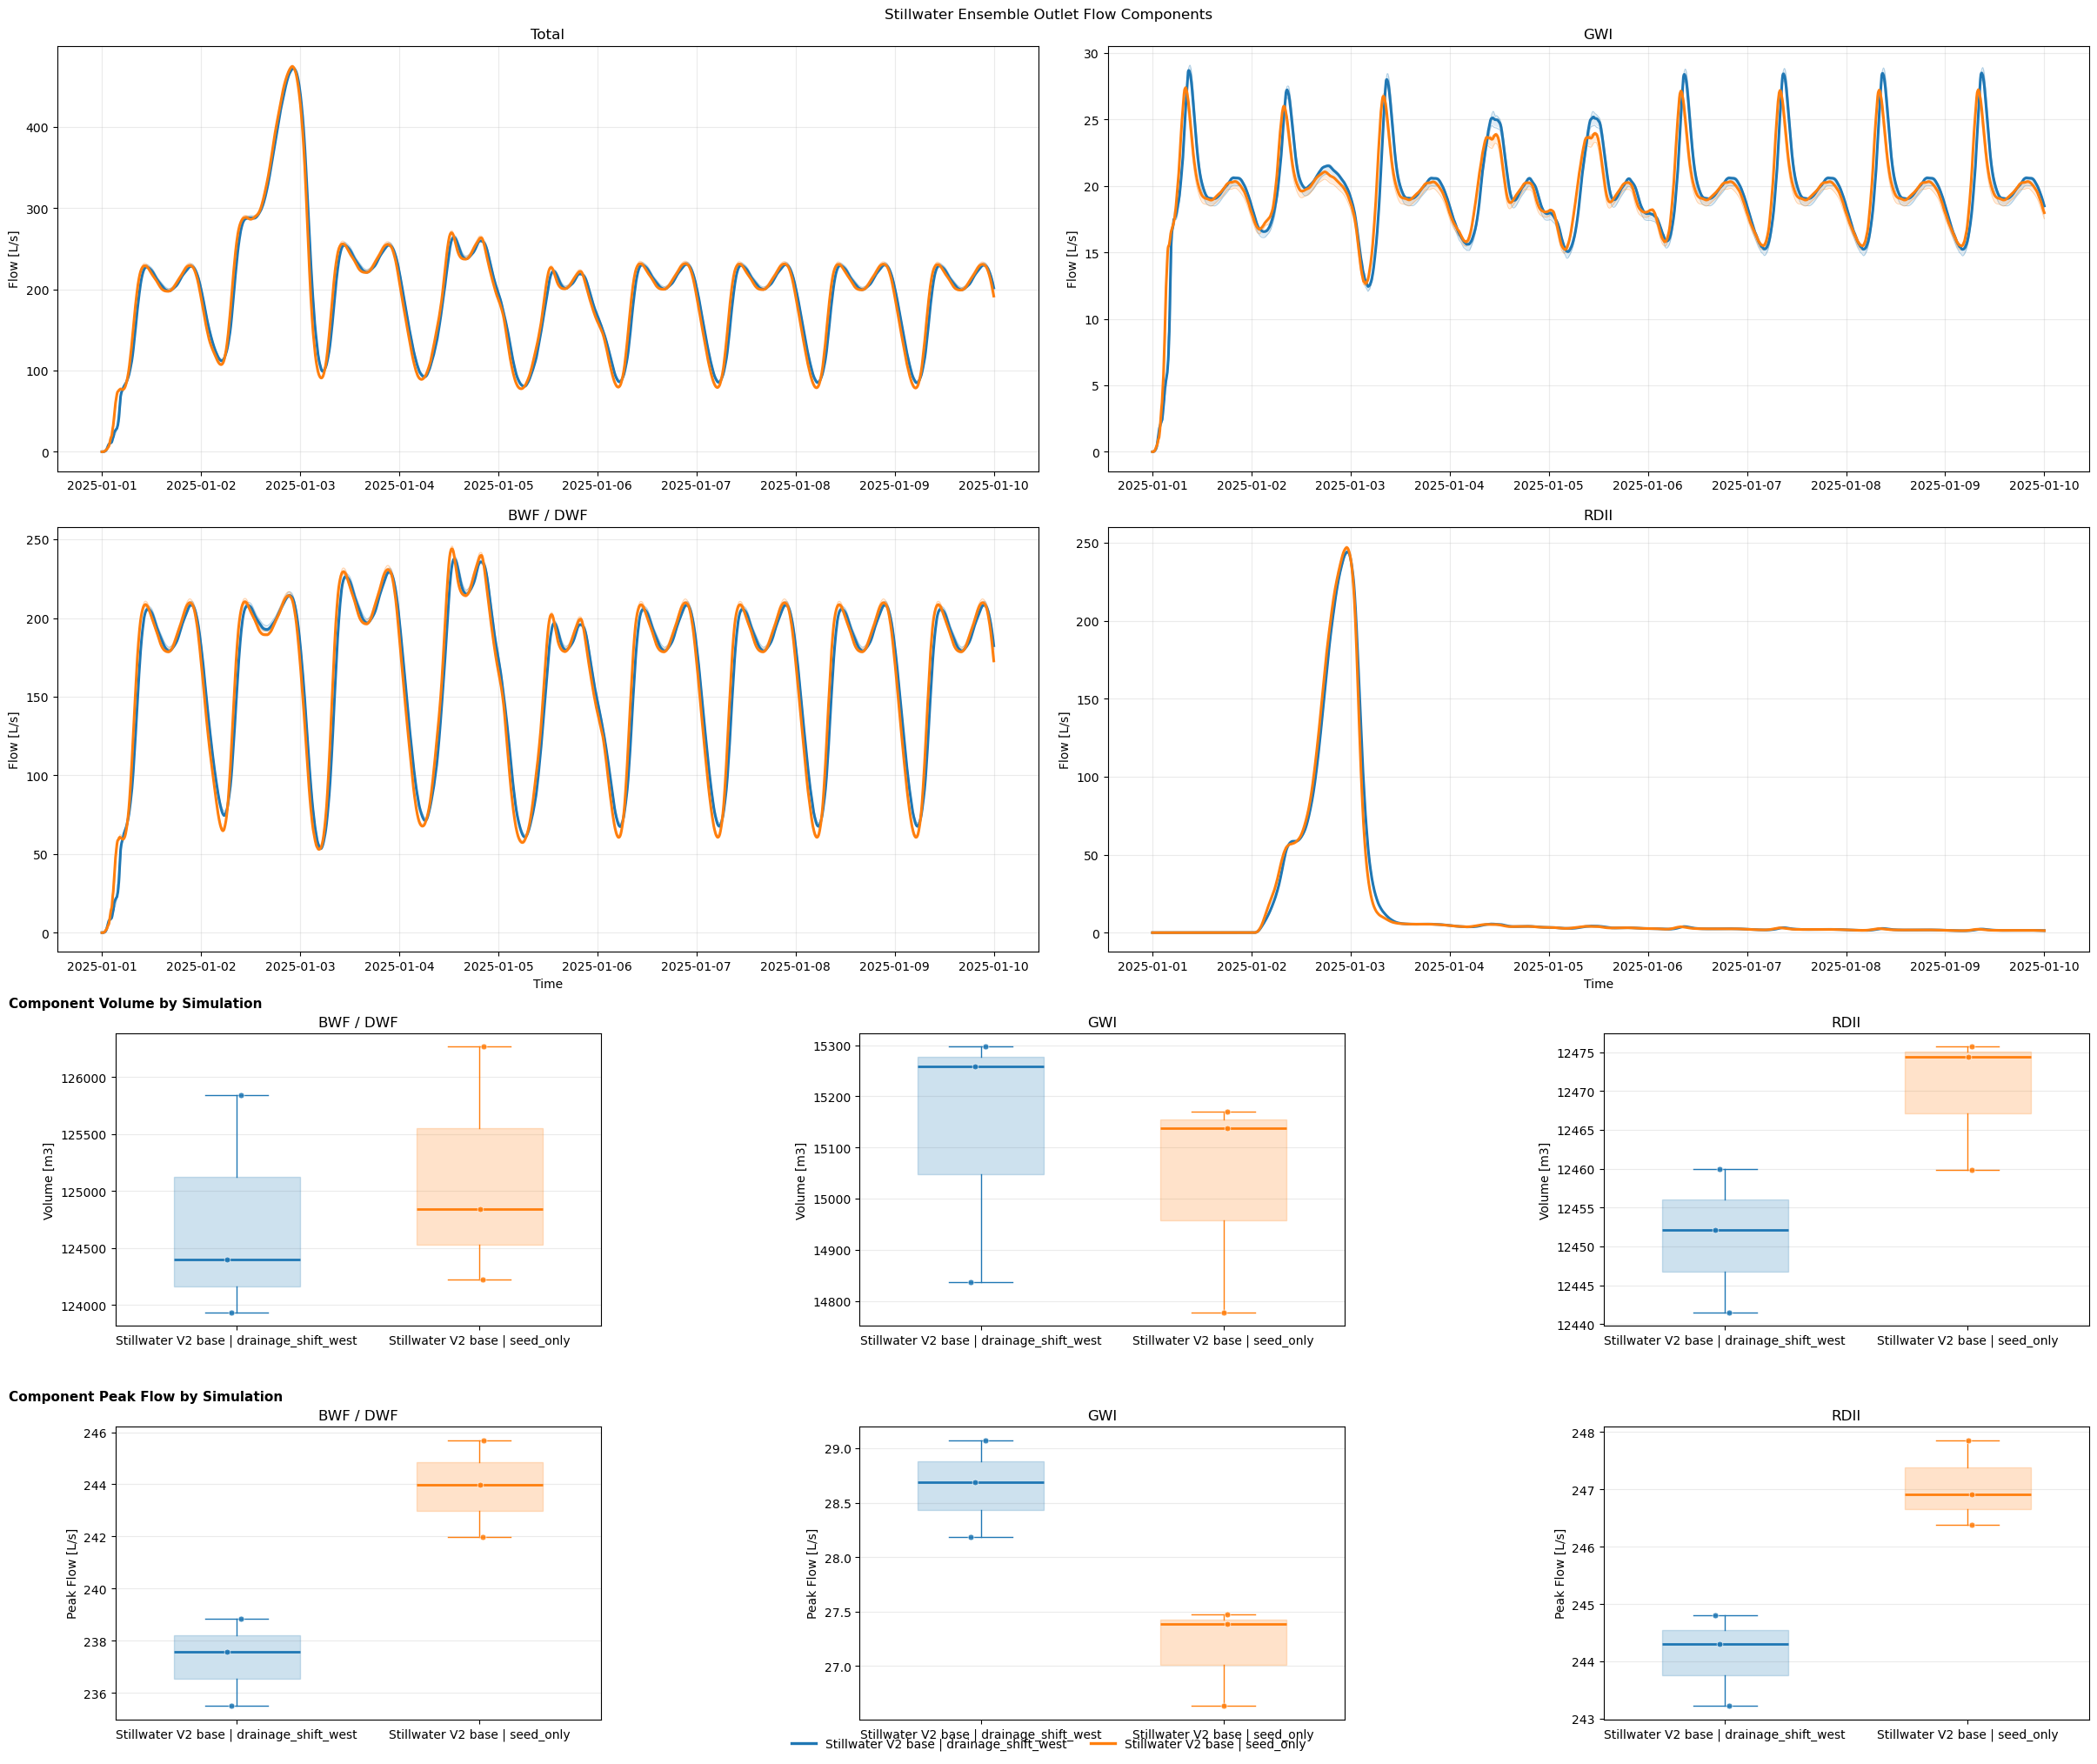

Saved figure: /Users/kevinblanco/Documents/Sewertris/examples/output_example_5_ensembles/ensemble_outlet_flow_comparison.png


,member_id,group_label,simulation_label,component,volume,peak_flow,flows_path,ensemble,realization,project_file,scenario_input,rerun_from,base_model,manifest_path,flows_exists
0,0,Stillwater V2 base | drainage_shift_west,Stillwater V2 base | drainage_shift_west #1,BWF / DWF,124397.909235,237.566222,/Users/kevinblanco/Documents/Sewertris/example...,drainage_shift_west,1,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
1,0,Stillwater V2 base | drainage_shift_west,Stillwater V2 base | drainage_shift_west #1,GWI,14836.219598,28.181956,/Users/kevinblanco/Documents/Sewertris/example...,drainage_shift_west,1,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
2,0,Stillwater V2 base | drainage_shift_west,Stillwater V2 base | drainage_shift_west #1,RDII,12452.075404,244.797297,/Users/kevinblanco/Documents/Sewertris/example...,drainage_shift_west,1,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
3,1,Stillwater V2 base | drainage_shift_west,Stillwater V2 base | drainage_shift_west #2,BWF / DWF,123933.633635,235.503816,/Users/kevinblanco/Documents/Sewertris/example...,drainage_shift_west,2,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
4,1,Stillwater V2 base | drainage_shift_west,Stillwater V2 base | drainage_shift_west #2,GWI,15258.360393,28.688535,/Users/kevinblanco/Documents/Sewertris/example...,drainage_shift_west,2,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True


In [3]:
START = None
END = None

if "flows_exists" in simulation_manifest.columns:
    available_manifest = simulation_manifest.loc[simulation_manifest["flows_exists"]].copy()
else:
    available_manifest = pd.DataFrame()

if available_manifest.empty:
    print("No completed flow-component files were found. Run notebook 05B first.")
else:
    fig, ensemble_summary = sp.plot_ensemble_results(
        available_manifest,
        group_cols=("base_model", "ensemble"),
        start=START,
        end=END,
        title="Stillwater Ensemble Outlet Flow Components",
        figsize=(24, 20),
        savepath=FIGURE_PATH,
        return_summary=True,
    )
    print("Saved figure:", FIGURE_PATH)
    display(ensemble_summary.head())

## Summary Tables

In [4]:
if "ensemble_summary" in globals() and not ensemble_summary.empty:
    volume_table = ensemble_summary.pivot_table(
        index=["base_model", "ensemble", "realization"],
        columns="component",
        values="volume",
    )
    peak_table = ensemble_summary.pivot_table(
        index=["base_model", "ensemble", "realization"],
        columns="component",
        values="peak_flow",
    )

    print("Component volumes")
    display(volume_table)
    print("Component peak flows")
    display(peak_table)
else:
    print("Run the dashboard cell first.")

Component volumes


component                                               BWF / DWF  \
base_model         ensemble            realization                  
Stillwater V2 base drainage_shift_west 1            124397.909235   
                                       2            123933.633635   
                                       3            125843.828908   
                   seed_only           1            124841.178441   
                                       2            124222.841467   
                                       3            126267.516031   

component                                                    GWI          RDII  
base_model         ensemble            realization                              
Stillwater V2 base drainage_shift_west 1            14836.219598  12452.075404  
                                       2            15258.360393  12460.007794  
                                       3            15297.340354  12441.486739  
                   seed_only           1            14777.370323  12474.397169  
                                       2            15138.684192  12475.713976  
                                       3            15169.921941  12459.799121

Component peak flows


component                                            BWF / DWF        GWI  \
base_model         ensemble            realization                          
Stillwater V2 base drainage_shift_west 1            237.566222  28.181956   
                                       2            235.503816  28.688535   
                                       3            238.854983  29.075398   
                   seed_only           1            243.974591  26.634332   
                                       2            241.971106  27.384295   
                                       3            245.696807  27.471470   

component                                                 RDII  
base_model         ensemble            realization              
Stillwater V2 base drainage_shift_west 1            244.797297  
                                       2            244.299014  
                                       3            243.221826  
                   seed_only           1            247.861559  
                                       2            246.919568  
                                       3            246.378966

In [5]:
import os

# Your code here
# ...

os.system('afplay /System/Library/Sounds/Hero.aiff')
os.system('say "Kevin, your simulation has finished."')

0